In [2]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [3]:
# Menggabungkan semua data dari semua file CSV
dataset = pd.read_csv('D:/KULIAH/TA-DESAK/model/sampling_fix.csv')

# Menampilkan informasi tentang dataset gabungan
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB
None


In [4]:
# Melihat unique value pada kolom "label"
dataset["Label"].unique()

array(['berlebihan', 'nonrelevan', 'relevan'], dtype=object)

In [5]:
# Hapus baris yang memiliki NaN di kolom "label"
dataset = dataset.dropna(subset=["Label"])

# Melihat unique value pada kolom "label"
dataset["Label"].unique()

array(['berlebihan', 'nonrelevan', 'relevan'], dtype=object)

In [6]:
dataset[dataset['Title_Summary'].isna()]

,Title_Summary,Label


In [7]:
dataset = dataset.dropna(subset=['Title_Summary'])

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB


In [8]:
dataset.head(20)

,Title_Summary,Label
0,"Senada dengan JK, Ketua Komisi X Mengaku Sorot...",berlebihan
1,Foto Perdana Baby Arkana Anak Ketiga Nikita Mi...,nonrelevan
2,Ungkapan Hati Tora Sudiro Usai Nikahkan Anak P...,relevan
3,"Kenakan Gaun Mewah, Jennie BLACKPINK Justru Di...",nonrelevan
4,Nadhila QP Ungkap Rahasia Kecantikan Alami di ...,nonrelevan
5,Mpok Alpa Berbagi Kisah Masa Kecil di Kampung ...,nonrelevan
6,"Soal UU KPK, Ketua Kadin: Baik untuk Kepastian...",berlebihan
7,Penjelasan Fuji soal Gaji Eks Manajer Rp 500 R...,relevan
8,Kondisi Terkini Nunung Usai Jalani Operasi Mat...,relevan
9,"NasDem Gabung Pemerintahan Prabowo-Gibran, Beg...",berlebihan


# Classification

In [9]:
import os
import re
import string
import numpy as np
import pandas as pd
import nltk
import tensorflow as tf

from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam, Adamax, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, SpatialDropout1D
from tensorflow.keras import regularizers

In [10]:
dataset['Label'].value_counts()

Label
relevan       4926
berlebihan    4890
nonrelevan    4500
Name: count, dtype: int64

In [11]:
dataset.groupby(dataset['Label']).count()

,Title_Summary
Label,
berlebihan,4890
nonrelevan,4500
relevan,4926


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

import warnings as wrn
wrn.filterwarnings('ignore', category = DeprecationWarning)
wrn.filterwarnings('ignore', category = FutureWarning)
wrn.filterwarnings('ignore', category = UserWarning)
wrn.filterwarnings('ignore', category = RuntimeWarning)

<Axes: title={'center': 'Category Count'}, xlabel='count', ylabel='Label'>

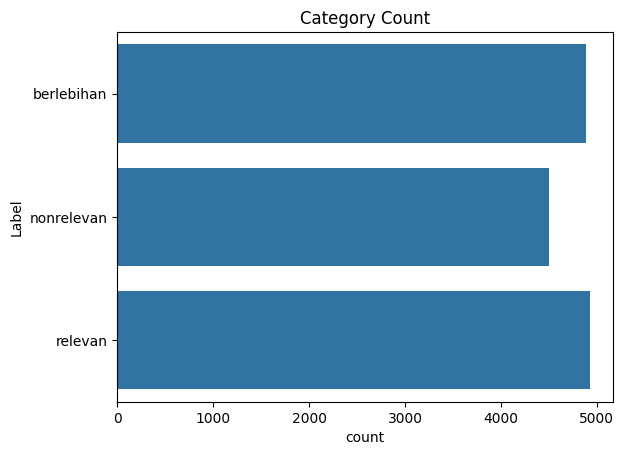

In [13]:
plt.title('Category Count')
sns.countplot(dataset['Label'])

In [14]:
kategori = pd.get_dummies(dataset.Label)
dataset = pd.concat([dataset, kategori], axis=1)
dataset = dataset.drop(columns='Label')
dataset.sample(5)

,Title_Summary,berlebihan,nonrelevan,relevan
4875,Perampok Minimarket Bersenjata Sangkur dan Pis...,True,False,False
1593,"Presiden Pertimbangkan Perppu KPK, Ketua DPR B...",False,True,False
4016,Satu Hakim yang Sidangkan Gazalba Saleh Disank...,False,False,True
13425,west mengadakan diakui bernyanyi kim hadiri sa...,False,True,False
8476,Lapor Pak! Ayu Ting Ting Pulang dari Amerika M...,True,False,False


In [15]:
feature = dataset['Title_Summary']
label = dataset[['berlebihan', 'nonrelevan', 'relevan']].values

In [16]:
from sklearn.model_selection import train_test_split
feature_latih, feature_test, label_latih, label_test = train_test_split(feature, label, test_size=0.2, random_state=42)

In [17]:
pad_type = 'pre'
trunc_type = 'pre'

# Tokenize our training data
tokenizer = Tokenizer(num_words=58700, oov_token='x')

tokenizer.fit_on_texts(feature_latih)

# # Hitung jumlah kata unik + 1 (karena index dimulai dari 1, dan 0 untuk padding)
# vocab_size = len(tokenizer.word_index) + 1
# print("Ukuran kosakata:", vocab_size)

# Encode training data sentences into sequences
sekuens_latih = tokenizer.texts_to_sequences(feature_latih)
sekuens_test = tokenizer.texts_to_sequences(feature_test)

# Get max training sequence length
maxlen = max([len(x) for x in sekuens_latih])

# Pad the training sequences
padded_latih = pad_sequences(sekuens_latih, padding=pad_type, truncating=trunc_type, maxlen=maxlen)
padded_test = pad_sequences(sekuens_test, padding=pad_type, truncating=trunc_type, maxlen=maxlen)

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=58700, output_dim=8, input_length=maxlen),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, maxlen))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 3039, 8)           469600    
                                                                 
 dropout (Dropout)           (None, 3039, 8)           0         
                                                                 
 lstm (LSTM)                 (None, 3039, 128)         70144     
                                                                 
 dropout_1 (Dropout)         (None, 3039, 128)         0         
                                                                 
 batch_normalization (BatchN  (None, 3039, 128)        512       
 ormalization)                                                   
                                                                 
 global_average_pooling1d (G  (None, 128)              0         
 lobalAveragePooling1D)                                 

In [19]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.9 and logs.get('val_accuracy')>0.9):
      print("\nAkurasi telah mencapai >90%!")
      self.model.stop_training = True
callbacks = myCallback()

In [20]:
num_epochs = 40
hist = model.fit(padded_latih, label_latih, epochs=num_epochs,
                    validation_data=(padded_test, label_test),
                    verbose=2, callbacks=[callbacks])

Epoch 1/40
358/358 - 106s - loss: 0.8684 - accuracy: 0.5821 - val_loss: 1.7578 - val_accuracy: 0.3097 - 106s/epoch - 297ms/step
Epoch 2/40
358/358 - 110s - loss: 0.6216 - accuracy: 0.7359 - val_loss: 4.0369 - val_accuracy: 0.3586 - 110s/epoch - 307ms/step
Epoch 3/40
358/358 - 109s - loss: 0.4366 - accuracy: 0.8337 - val_loss: 5.1667 - val_accuracy: 0.3865 - 109s/epoch - 305ms/step
Epoch 4/40
358/358 - 113s - loss: 0.3319 - accuracy: 0.8801 - val_loss: 7.0923 - val_accuracy: 0.4431 - 113s/epoch - 314ms/step
Epoch 5/40
358/358 - 120s - loss: 0.2629 - accuracy: 0.9106 - val_loss: 0.7149 - val_accuracy: 0.7374 - 120s/epoch - 336ms/step
Epoch 6/40
358/358 - 122s - loss: 0.2232 - accuracy: 0.9255 - val_loss: 0.7325 - val_accuracy: 0.8017 - 122s/epoch - 341ms/step
Epoch 7/40
358/358 - 122s - loss: 0.1889 - accuracy: 0.9377 - val_loss: 12.5256 - val_accuracy: 0.4476 - 122s/epoch - 341ms/step
Epoch 8/40
358/358 - 120s - loss: 0.1708 - accuracy: 0.9402 - val_loss: 2.3263 - val_accuracy: 0.6236 -

90/90 [==============================] - 12s 128ms/step


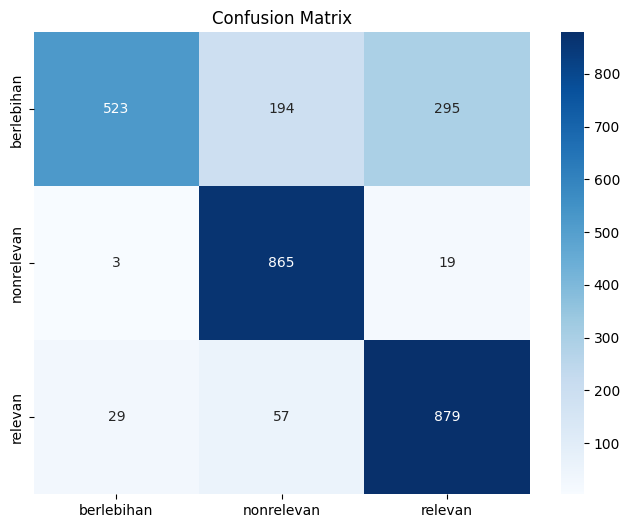

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Prediksi label dari data uji
label_prediksi = model.predict(padded_test)
label_prediksi = [list(prediksi).index(max(prediksi)) for prediksi in label_prediksi]

# Konversi one-hot encoded labels menjadi label kelas tunggal
label_asli = [list(label).index(1) for label in label_test]

# Buat confusion matrix
cm = confusion_matrix(label_asli, label_prediksi)

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['berlebihan', 'nonrelevan', 'relevan'], yticklabels=['berlebihan', 'nonrelevan', 'relevan'])
plt.title('Confusion Matrix')
plt.show()

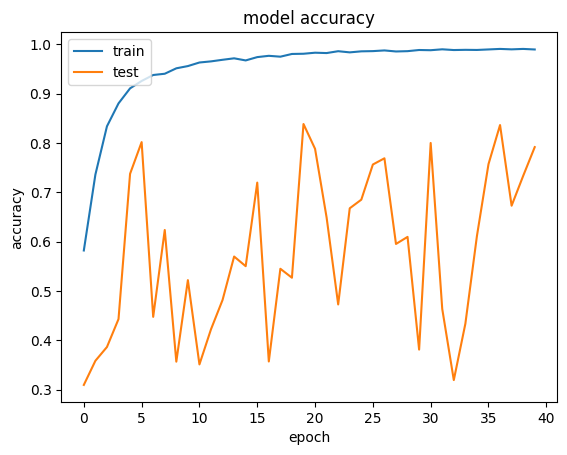

In [22]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

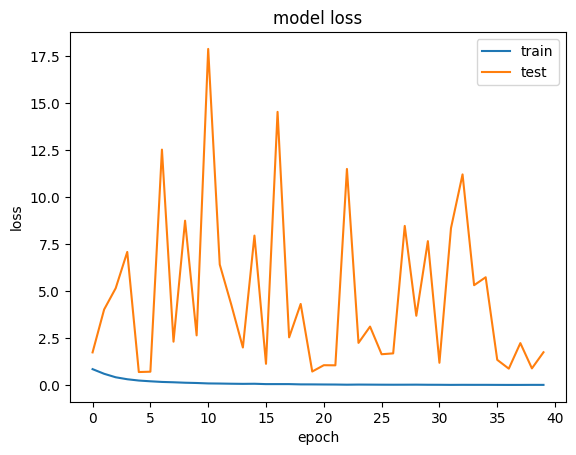

In [23]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Prediksi label dari data uji
label_prediksi = model.predict(padded_test)
label_prediksi = [list(prediksi).index(max(prediksi)) for prediksi in label_prediksi]

# Konversi one-hot encoded labels menjadi label kelas tunggal
label_asli = [list(label).index(1) for label in label_test]

# Hitung akurasi
accuracy = sum([1 for true, pred in zip(label_asli, label_prediksi) if true == pred]) / len(label_asli)
print(f"Akurasi pada data uji: {accuracy * 100:.2f}%")

# Hitung Precision, Recall, dan F1-Score
precision = precision_score(label_asli, label_prediksi, average='weighted')
recall = recall_score(label_asli, label_prediksi, average='weighted')
f1 = f1_score(label_asli, label_prediksi, average='weighted')

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")


90/90 [==============================] - 11s 124ms/step
Akurasi pada data uji: 79.16%
Precision: 0.821
Recall: 0.792
F1-Score: 0.778


In [25]:
from sklearn.metrics import classification_report

# Menghitung Precision, Recall, dan F1-Score
report = classification_report(label_asli, label_prediksi, target_names=['berlebihan', 'nonrelevan', 'relevan'])
print(report)

              precision    recall  f1-score   support

  berlebihan       0.94      0.52      0.67      1012
  nonrelevan       0.78      0.98      0.86       887
     relevan       0.74      0.91      0.81       965

    accuracy                           0.79      2864
   macro avg       0.82      0.80      0.78      2864
weighted avg       0.82      0.79      0.78      2864



In [26]:
import pickle
# Save the model to a file
model.save('modellstm_coba08.h5')

# Save the tokenizer to a file using pickle
with open('tokenizer_coba08.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

## ROC-Curve

In [27]:
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [28]:
# 1. Load tokenizer
with open('tokenizer_coba08.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

# 2. Tokenisasi dan padding untuk feature_test
sekuens_test = tokenizer.texts_to_sequences(feature_test)

# Gunakan pad_type, trunc_type, dan maxlen yang sama seperti training
pad_type = 'pre'
trunc_type = 'pre'
maxlen = max([len(x) for x in tokenizer.texts_to_sequences(feature_latih)])  # <- Sama seperti saat training

padded_test = pad_sequences(sekuens_test, padding=pad_type, truncating=trunc_type, maxlen=maxlen)

# 3. Load model
model = load_model('modellstm_coba08.h5')

# 4. Prediksi probabilitas
y_score = model.predict(padded_test)

90/90 [==============================] - 12s 122ms/step


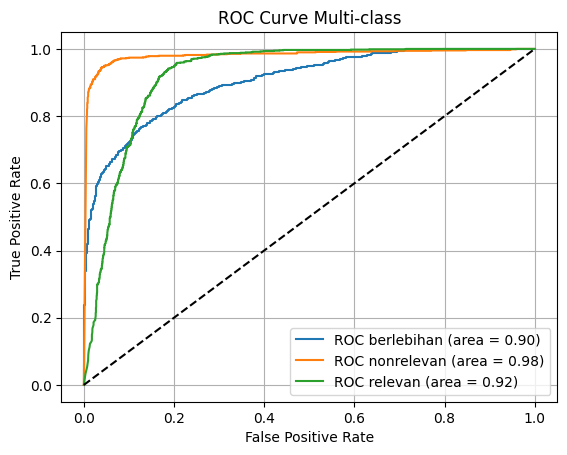

In [29]:

target_names = ['berlebihan', 'nonrelevan', 'relevan']
n_target = len(target_names)

# Binarisasi label_test (kalau label_test kamu berupa angka: 0, 1, 2)
y_true = label_binarize(label_test, classes=range(n_target))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_target):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC {target_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multi-class')
plt.legend(loc='lower right')
plt.grid()
plt.show()